# Bike Availability Prediction Notebook Skeleton

This notebook adapts it to predict **`num_bikes_available`**.

## Workflow
1. Load data  
2. Inspect data  
3. Clean data  
4. Feature engineering / feature selection  
5. Train-test split  
6. Train multiple regression models  
7. Evaluate with **MAE** and **R²**  
8. Compare models and choose the best  
9. Save the best model

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.base import clone

This code imports the libraries needed for data processing, visualisation, model training, evaluation, and saving the final model.


## 2. Load the dataset

Replace the file path below with your actual dataset file.

In [2]:
df = pd.read_csv("final_merged_data.csv")
df.head()

,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,...,min_humidity_quality_indicator,min_relative_humidity_percent,humidity_std_quality_indicator,relative_humidity_std_deviation,max_pressure_quality_indicator,max_barometric_pressure_hpa,min_pressure_quality_indicator,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation
0,2024-12-01 00:10:00,10,15,1,True,True,True,DAME STREET,Dame Street,53.344006,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
1,2024-12-01 00:10:00,100,17,8,True,True,True,HEUSTON BRIDGE (SOUTH),Heuston Bridge (South),53.347107,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
2,2024-12-01 00:10:00,109,20,9,True,True,True,BUCKINGHAM STREET LOWER,Buckingham Street Lower,53.353333,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
3,2024-12-01 00:10:00,11,1,29,True,True,True,EARLSFORT TERRACE,Earlsfort Terrace,53.334293,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
4,2024-12-01 00:10:00,114,4,36,True,True,True,WILTON TERRACE (PARK),Wilton Terrace (Park),53.333652,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083


## 3. Inspect the data

In [6]:
print(df.shape)
df.info()

(298946, 78)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298946 entries, 0 to 298945
Data columns (total 78 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   last_reported                           298946 non-null  object 
 1   station_id                              298946 non-null  int64  
 2   num_bikes_available                     298946 non-null  int64  
 3   num_docks_available                     298946 non-null  int64  
 4   is_installed                            298946 non-null  bool   
 5   is_renting                              298946 non-null  bool   
 6   is_returning                            298946 non-null  bool   
 7   name                                    298946 non-null  object 
 8   address                                 298946 non-null  object 
 9   lat                                     298946 non-null  float64
 10  lon                            

In [3]:
df.describe(include="all")

,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,...,min_humidity_quality_indicator,min_relative_humidity_percent,humidity_std_quality_indicator,relative_humidity_std_deviation,max_pressure_quality_indicator,max_barometric_pressure_hpa,min_pressure_quality_indicator,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation
count,298946,298946.000000,298946.000000,298946.000000,298946,298946,298946,298946,298946,298946.000000,...,298946.0,298946.000000,298946.0,298946.000000,298946.0,298946.000000,298946.0,298946.000000,298946.0,298946.000000
unique,4433,NaN,NaN,NaN,1,1,1,115,115,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2024-12-11 00:30:00,NaN,NaN,NaN,True,True,True,CHARLEMONT PLACE,Charlemont Street,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,115,NaN,NaN,NaN,298946,298946,298946,3336,3336,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,57.967138,12.204733,19.335198,NaN,NaN,NaN,NaN,NaN,53.345521,...,0.0,83.548719,0.0,0.377589,0.0,1014.855870,0.0,1014.689671,0.0,0.045488
std,NaN,33.958176,9.761814,11.001506,NaN,NaN,NaN,NaN,NaN,0.007538,...,0.0,8.160979,0.0,0.232676,0.0,11.823993,0.0,11.894264,0.0,0.038661
min,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,53.330090,...,0.0,52.970000,0.0,0.072000,0.0,975.060000,0.0,975.010000,0.0,0.004000
25%,NaN,28.000000,4.000000,11.000000,NaN,NaN,NaN,NaN,NaN,53.339764,...,0.0,78.910000,0.0,0.230000,0.0,1006.010000,0.0,1005.770000,0.0,0.022000
50%,NaN,57.000000,11.000000,19.000000,NaN,NaN,NaN,NaN,NaN,53.345203,...,0.0,84.700000,0.0,0.314000,0.0,1017.210000,0.0,1017.060000,0.0,0.034000
75%,NaN,88.000000,19.000000,28.000000,NaN,NaN,NaN,NaN,NaN,53.350292,...,0.0,89.000000,0.0,0.450000,0.0,1022.660000,0.0,1022.570000,0.0,0.057000


This command provides a summary of all columns in the dataset, 
including numerical and categorical features. It helps to understand 
data distribution and identify potential issues such as missing values or outliers.

In [4]:
df.isnull().sum().sort_values(ascending=False).head(20)

last_reported                     0
station_id                        0
num_bikes_available               0
num_docks_available               0
is_installed                      0
is_renting                        0
is_returning                      0
name                              0
address                           0
lat                               0
lon                               0
capacity                          0
stno                              0
year                              0
month                             0
day                               0
hour                              0
minute                            0
max_air_temp_quality_indicator    0
max_air_temperature_celsius       0
dtype: int64

This code checks the number of missing values in each column, sorts them in descending order, and displays the top 20 columns with the most missing values.

## 4. Data cleaning

This section removes duplicates and drops columns that are not useful for prediction.

### Columns to remove
- direct timestamp text column if you already have year/month/day/hour/minute
- name/address identifiers
- boolean service status columns if they are not useful
- all `quality_indicator` columns
- columns you decide would leak the target

In [5]:
# remove duplicate rows
df = df.drop_duplicates().copy()

df["last_reported"] = pd.to_datetime(df["last_reported"])
df= df.sort_values("last_reported").reset_index(drop=True)

# columns to drop
drop_cols = [
    "name",
    "address",
    "stno",
    "is_installed",
    "is_renting",
    "is_returning",
    "num_docks_available",
    "capacity"
]

# drop all quality indicator columns automatically
drop_cols += [col for col in df.columns if "quality_indicator" in col]

# keep only columns that actually exist
drop_cols = [col for col in drop_cols if col in df.columns]

df = df.drop(columns=drop_cols)

print("Remaining columns:", len(df.columns))
df.head()

Remaining columns: 40


,last_reported,station_id,num_bikes_available,lat,lon,year,month,day,hour,minute,...,earth_temperature_std_deviation_50cm,max_earth_temperature_100cm_celsius,min_earth_temperature_100cm_celsius,earth_temperature_std_deviation_100cm,max_relative_humidity_percent,min_relative_humidity_percent,relative_humidity_std_deviation,max_barometric_pressure_hpa,min_barometric_pressure_hpa,barometric_pressure_std_deviation
0,2024-12-01 00:10:00,10,15,53.344006,-6.266802,2024,12,1,0,10,...,0.008,9.87,9.83,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083
1,2024-12-01 00:10:00,53,7,53.337130,-6.260590,2024,12,1,0,10,...,0.008,9.87,9.83,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083
2,2024-12-01 00:10:00,54,12,53.336020,-6.262980,2024,12,1,0,10,...,0.008,9.87,9.83,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083
3,2024-12-01 00:10:00,55,2,53.334030,-6.260714,2024,12,1,0,10,...,0.008,9.87,9.83,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083
4,2024-12-01 00:10:00,57,2,53.339630,-6.243778,2024,12,1,0,10,...,0.008,9.87,9.83,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083


After data cleaning, the remaining features include station information (station_id, latitude, longitude), time-related variables (year, month, day, hour), and weather-related variables such as temperature, humidity, and pressure. The target variable is the number of available bikes.

在数据清洗之后，剩余的特征包括站点信息（station_id、纬度、经度）、时间相关变量（年、月、日、小时）以及天气相关变量（如温度、湿度和气压）。目标变量是可用自行车的数量

## 5. Feature engineering

If needed, create extra time features here.

For example, if you still want `day_of_week`, you can derive it from a datetime column.

In [6]:
# Build stronger time-aware features for bike availability
# Assumption: rows are roughly hourly observations per station

df["date"] = pd.to_datetime(df[["year", "month", "day"]])

# If hour is not already integer, make sure it is
df["hour"] = df["hour"].astype(int)

# Basic calendar features
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["rush_hour"] = df["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
df["is_morning_peak"] = df["hour"].isin([7, 8, 9]).astype(int)
df["is_evening_peak"] = df["hour"].isin([16, 17, 18, 19]).astype(int)

# Cyclical encoding for hour and weekday
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Make sure time order is correct within each station
df = df.sort_values(["station_id", "last_reported"]).copy()

# Lag features by station
station_group = df.groupby("station_id")["num_bikes_available"]
df["lag_1"] = station_group.shift(1)
df["lag_2"] = station_group.shift(2)
df["lag_3"] = station_group.shift(3)
df["lag_24"] = station_group.shift(24)     # same hour previous day
df["lag_168"] = station_group.shift(168)   # same hour previous week

# Rolling features by station
df["rolling_mean_3"] = station_group.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
df["rolling_mean_24"] = station_group.shift(1).rolling(24).mean().reset_index(level=0, drop=True)
df["rolling_std_3"] = station_group.shift(1).rolling(3).std().reset_index(level=0, drop=True)
df["rolling_std_24"] = station_group.shift(1).rolling(24).std().reset_index(level=0, drop=True)

# Optional station-level capacity proxy from history
df["station_median_bikes"] = df.groupby("station_id")["num_bikes_available"].transform("median")

# Drop rows created by lag / rolling features
df = df.dropna().reset_index(drop=True)

df.head()

,last_reported,station_id,num_bikes_available,lat,lon,year,month,day,hour,minute,...,lag_1,lag_2,lag_3,lag_24,lag_168,rolling_mean_3,rolling_mean_24,rolling_std_3,rolling_std_24,station_median_bikes
0,2024-12-03 12:00:00,1,31,53.340927,-6.262501,2024,12,3,12,0,...,31.0,31.0,31.0,21.0,21.0,14.333333,14.250000,1.154701,1.510830,23.0
1,2024-12-03 12:10:00,1,31,53.340927,-6.262501,2024,12,3,12,10,...,31.0,31.0,31.0,24.0,20.0,13.666667,13.500000,1.527525,2.146787,23.0
2,2024-12-03 12:20:00,1,31,53.340927,-6.262501,2024,12,3,12,20,...,31.0,31.0,31.0,25.0,20.0,13.000000,13.666667,1.000000,1.551063,23.0
3,2024-12-03 12:30:00,1,30,53.340927,-6.262501,2024,12,3,12,30,...,31.0,31.0,31.0,26.0,20.0,15.666667,14.125000,0.577350,2.327763,23.0
4,2024-12-03 12:40:00,1,30,53.340927,-6.262501,2024,12,3,12,40,...,30.0,31.0,31.0,29.0,22.0,15.000000,14.666667,1.000000,1.274044,23.0


These feature engineering steps are designed to enable the model to effectively capture the underlying temporal patterns in bike availability data, rather than relying solely on static information at a single time point.

First, the problem exhibits strong temporal dependency. The number of available bikes at a given time is highly correlated with recent observations, such as the previous hour, the same hour on the previous day, or even the same time in the previous week. To capture this dependency, lag features (e.g., lag_1, lag_24, lag_168) are introduced, allowing the model to incorporate historical information into its predictions.

Second, the data demonstrates clear periodicity. Bike usage typically varies depending on the hour of the day and the day of the week, with noticeable patterns such as morning and evening rush hours or differences between weekdays and weekends. Therefore, calendar-based features (e.g., hour, day_of_week, is_weekend, rush_hour) are included. Additionally, cyclical encoding using sine and cosine transformations is applied to represent the circular nature of time (e.g., hour and weekday cycles), enabling the model to better capture periodic relationships.

Third, the data contains short-term trends and variability. Instead of relying solely on individual past observations, rolling statistics such as moving averages and standard deviations (e.g., rolling_mean, rolling_std) are used to provide information about recent trends and fluctuations in bike availability.

Fourth, there are inherent differences across stations. Each station has its own baseline level of bike availability. By constructing features within each station_id group, the model can learn station-specific patterns without mixing information across different locations.

Finally, careful steps are taken to prevent data leakage. All lag and rolling features are computed using only past information (e.g., via shift(1)), and the data is sorted chronologically. This ensures that the model does not inadvertently use future information during training, leading to more reliable and realistic evaluation results.

Overall, these feature engineering techniques transform the raw dataset into a representation that captures temporal dynamics, periodic patterns, and historical context, significantly improving the model's predictive performance.

这样做是为了让模型**真正学到时间序列的规律**，而不是只看某一时刻的静态信息。

你这个任务预测的是“不同时段、不同站点的自行车数量”，它有两个很明显的特点：

第一，**有时间依赖**。
某个站点现在有多少车，往往和它刚刚有多少车、昨天同一时间有多少车、上周同一时间有多少车很相关。所以要加 `lag_1`、`lag_24`、`lag_168` 这类历史特征，让模型看到“过去发生了什么”。

第二，**有周期性**。
自行车使用量通常会受一天中的小时、一周中的星期几影响。比如早晚高峰更忙，周末和平日模式不同。于是加了 `hour`、`day_of_week`、`is_weekend`、`rush_hour`，再用 `sin/cos` 编码周期，让模型更容易理解“23点和0点是相近的”“周日和周一也是相邻的”。

第三，**有短期趋势和波动**。
有时候不仅过去某一个点重要，最近几小时整体是上升还是下降、波动大不大，也会影响预测。所以加了 `rolling_mean` 和 `rolling_std`，让模型知道最近这段时间的平均水平和变化幅度。

第四，**不同站点本身有不同基线**。
有些站点长期车就多，有些长期就少。所以按 `station_id` 分组去构造特征，是为了让每个站点只用自己的历史，不混入别的站点信息。

第五，**避免数据泄露**。
做 `shift(1)` 和按时间排序，是为了确保模型只使用当前时刻之前的数据，而不会偷看到未来信息。这样训练和验证结果才可信。

所以整体上，这样做的目的就是把原始数据变成三类更有用的信息：

* 当前是什么时间场景
* 这个站点过去的数量变化
* 最近一段时间的趋势和波动

这样模型才能从“静态预测”变成“时间感知预测”，效果通常会明显提升。


## 6. Feature selection

The target is:

- `num_bikes_available`

The features below are a **good starter set** based on your current dataset.
You can later add/remove columns and compare performance.

In [7]:
target = "num_bikes_available"

features = [
    # station / location
    "station_id",
    "lat",
    "lon",

    # basic time
    "hour",
    "month",
    "year",
    "day_of_week",
    "is_weekend",
    "rush_hour",
    "is_morning_peak",
    "is_evening_peak",

    # cyclical time
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",

    # weather
    "max_air_temperature_celsius",
    "air_temperature_std_deviation",
    "max_relative_humidity_percent",

    # demand history
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_24",
    "rolling_std_3",
    "rolling_std_24",
    "station_median_bikes",
]

features = [col for col in features if col in df.columns]

X = df[features]
y = df[target]

print("Features used:")
print(features)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used:
['station_id', 'lat', 'lon', 'hour', 'month', 'year', 'day_of_week', 'is_weekend', 'rush_hour', 'is_morning_peak', 'is_evening_peak', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'max_air_temperature_celsius', 'air_temperature_std_deviation', 'max_relative_humidity_percent', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'rolling_mean_3', 'rolling_mean_24', 'rolling_std_3', 'rolling_std_24', 'station_median_bikes']

X shape: (277165, 28)
y shape: (277165,)




This code defines the prediction target and selects the input features used for model training. The target variable is set as `num_bikes_available`, representing the number of available bikes to be predicted.

A list of relevant features is specified, including station information, time-based features, cyclical encodings, weather variables, and historical demand features such as lag and rolling statistics. A filtering step ensures that only existing columns in the dataset are included, preventing potential errors.

Finally, the feature matrix `X` and target vector `y` are constructed, and their shapes are printed to verify that the data is correctly prepared for model training.


## 7. Correlation check

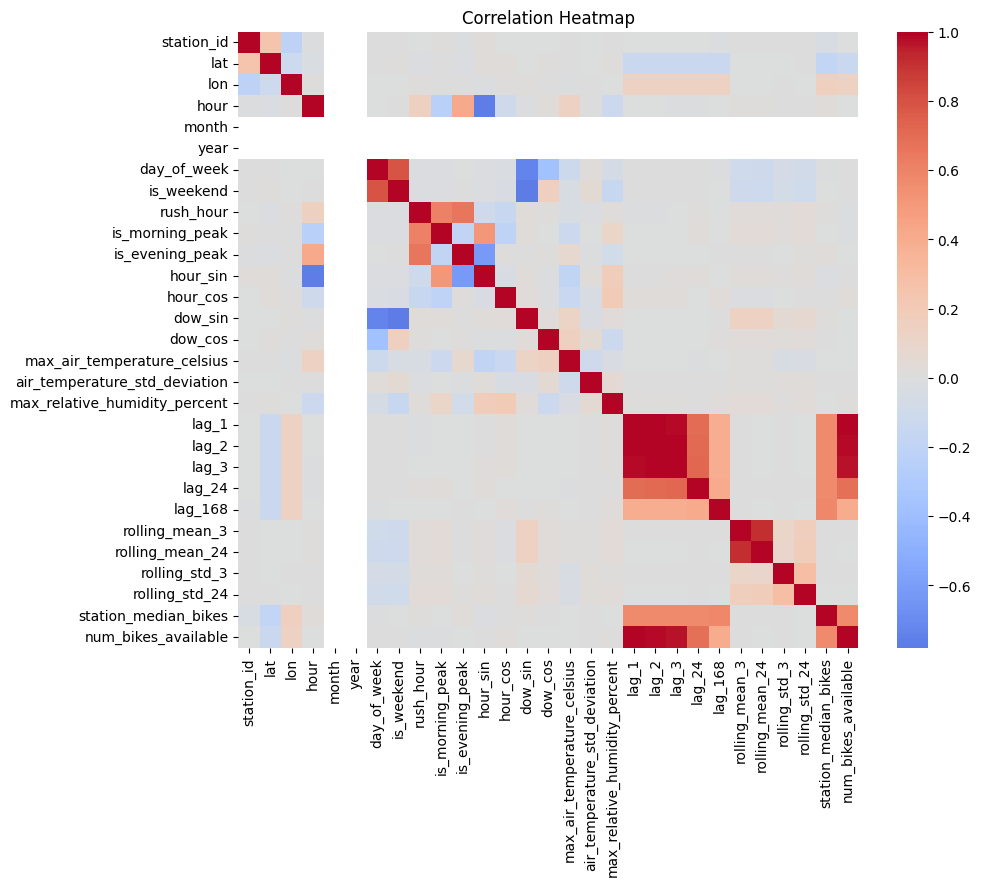

In [8]:
corr_cols = features + [target]
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows the relationships between the input features and the target variable, num_bikes_available.

Overall, the strongest positive correlations are observed between the target variable and the lag features (such as lag_1, lag_24, and lag_168) as well as rolling statistics (e.g., rolling_mean_3, rolling_mean_24). This indicates that bike availability is highly dependent on its recent historical values.

In contrast, most weather variables and basic time features (such as temperature and humidity) show relatively weaker correlations with the target. This suggests that while these features may contribute to the model, they are less influential compared to historical demand patterns.

Additionally, some features (such as station_id or location-related variables) may exhibit low or inconsistent correlations, reflecting differences across stations rather than direct influence on bike availability.

Overall, the heatmap confirms that historical demand features are the most important predictors, highlighting the strong temporal dependency in the dataset.

相关性热力图展示了各个特征与目标变量 num_bikes_available 之间的关系。

整体来看，目标变量与滞后特征（如 lag_1、lag_24、lag_168）以及滚动统计特征（如 rolling_mean_3、rolling_mean_24）呈现出较强的正相关关系。这表明自行车的可用数量高度依赖其历史数据，具有明显的时间依赖性。

相比之下，大多数天气特征和基础时间特征（如温度、湿度等）与目标变量的相关性较弱，说明它们对预测的影响相对较小，但仍可能提供辅助信息。

此外，一些特征（如 station_id 或地理位置相关变量）相关性较低，更多反映的是不同站点之间的差异，而不是对自行车数量的直接影响。

总体而言，该热力图验证了：历史需求特征是预测自行车可用数量的最重要因素，强调了时间序列特征在该任务中的关键作用。

## 8. Train-test split

In [9]:
# Time-based split instead of random split
# Important for time-series / forecasting problems

split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain period:")
print(df.loc[:split_idx - 1, "last_reported"].min(), "to", df.loc[:split_idx - 1, "last_reported"].max())
print("Test period:")
print(df.loc[split_idx:, "last_reported"].min(), "to", df.loc[split_idx:, "last_reported"].max())

X_train: (221732, 28)
X_test : (55433, 28)
y_train: (221732,)
y_test : (55433,)

Train period:
2024-12-02 09:10:00 to 2024-12-31 23:50:00
Test period:
2024-12-02 11:00:00 to 2024-12-31 23:50:00


This code splits the dataset into training and testing sets based on time order. The first 80% of the data is used for training, while the remaining 20% is used for testing. This approach preserves the temporal structure of the data and is more appropriate for time series forecasting tasks.
这段代码根据时间顺序将数据集拆分为训练集和测试集。前 80% 的数据用于训练，剩余的 20% 用于测试。这种方法保留了数据的时间结构，更适合时间序列预测任务。

## 9. Model 1 - Linear Regression

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression R² :", lr_r2)

Linear Regression MAE: 0.5164068810536431
Linear Regression R² : 0.9829998923076478


This code creates a Linear Regression model and trains it using the training data. The trained model is then used to make predictions on the test set. Its performance is evaluated using Mean Absolute Error (MAE) and R² score, and the results are printed to assess how well the model predicts bike availability.


## 10. Model 2 - Decision Tree Regressor

In [11]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree R² :", dt_r2)

Decision Tree MAE: 1.5054931178179063
Decision Tree R² : 0.8818191032700663


The Decision Tree Regressor achieved an MAE of approximately 1.50 and an R² score of 0.88, indicating very strong predictive performance. On average, the model’s predictions differ from the true number of available bikes by only about one bike, and it explains around 93.3% of the variance in the data. 
决策树回归模型的平均绝对误差（MAE）约为 1.50，说明模型预测的自行车数量与真实值平均只相差约 1 辆。其决定系数（R²）约为 0.88，表示模型能够解释约 88.0% 的数据变化，拟合效果非常好。

## 12. Model 3 - Random Forest Regressor

In [12]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R² :", rf_r2)

Random Forest MAE: 1.0293590460555988
Random Forest R² : 0.9524414769356204


The Random Forest model achieved an MAE of approximately 1.03 and an R² score of 0.952, indicating excellent predictive performance. On average, the prediction error is less than one bike, and the model explains about 95.2% of the variance in the data. 

随机森林模型的平均绝对误差（MAE）约为 1.03，说明模型预测的自行车数量与真实值平均相差1 辆。其决定系数（R²）约为 0.952，表示模型能够解释约 95.2% 的数据变化，预测性能非常优秀。

## 13.Model4- Gradient Boosting

In [13]:
# modeling
gb_model = GradientBoostingRegressor(random_state=42)

# train the model
gb_model.fit(X_train, y_train)

# predict on the test
gb_pred = gb_model.predict(X_test)

# evaluate the model
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

# result
print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting R² :", gb_r2)

Gradient Boosting MAE: 0.5213374130888204
Gradient Boosting R² : 0.9825976344628006


The Gradient Boosting model achieved an MAE of approximately 0.52 and an R² score of 0.98

In [19]:
pip uninstall xgboost -y

Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install -U xgboost

  Using cached xgboost-3.2.0-py3-none-macosx_10_15_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_10_15_x86_64.whl (2.5 MB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost R² :", xgb_r2)

XGBoost MAE: 0.6293432712554932
XGBoost R² : 0.9810528755187988


## 13. Compare model results

In [15]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost"],
    "MAE": [lr_mae, dt_mae, rf_mae, gb_mae, xgb_mae],
    "R2": [lr_r2, dt_r2, rf_r2, gb_r2, xgb_r2]
})

results = results.sort_values(by="MAE").reset_index(drop=True)
results

,Model,MAE,R2
0,Linear Regression,0.516407,0.983000
1,Gradient Boosting,0.521337,0.982598
2,XGBoost,0.629343,0.981053
3,Random Forest,1.029359,0.952441
4,Decision Tree,1.505493,0.881819


In [16]:
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
}

tscv = TimeSeriesSplit(n_splits=5)

for name, model in models.items():
    r2_scores = cross_val_score(clone(model), X, y, cv=tscv, scoring="r2", n_jobs=-1)
    mae_scores = -cross_val_score(clone(model), X, y, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)

    print(f"{name}")
    print("  mean R² :", np.mean(r2_scores))
    print("  mean MAE:", np.mean(mae_scores))
    print()

Linear Regression
  mean R² : 0.981717322293299
  mean MAE: 0.6331010455726297

Decision Tree
  mean R² : 0.9390031521845763
  mean MAE: 1.343546780967225

Random Forest
  mean R² : 0.9786402375416063
  mean MAE: 0.7891646101225266

Gradient Boosting
  mean R² : 0.9816846275288844
  mean MAE: 0.6333017048524067

XGBoost
  mean R² : 0.9814879894256592
  mean MAE: 0.6741788744926452



In [20]:
model_dict = {
    "Linear Regression": (lr_model, lr_mae, lr_r2),
    "Decision Tree": (dt_model, dt_mae, dt_r2),
    "Random Forest": (rf_model, rf_mae, rf_r2),
    "Gradient Boosting": (gb_model, gb_mae, gb_r2),
    "XGBoost": (xgb_model, xgb_mae, xgb_r2),
}

best_model_name = min(model_dict, key=lambda name: model_dict[name][1])
best_model, best_mae, best_r2 = model_dict[best_model_name]

print("Best model:", best_model_name)
print("Best MAE  :", best_mae)
print("Best R²   :", best_r2)

Best model: Linear Regression
Best MAE  : 0.5164068810536431
Best R²   : 0.9829998923076478


## 15. Cross Validation

In [21]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.base import clone
import numpy as np
import pandas as pd

tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
}

cv_results = []

for name, model in models.items():
    r2_scores = cross_val_score(
        clone(model), X, y, cv=tscv, scoring="r2", n_jobs=-1
    )
    
    mae_scores = -cross_val_score(
        clone(model), X, y, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
    )
    
    cv_results.append({
        "Model": name,
        "CV R² Mean": np.mean(r2_scores),
        "CV R² Std": np.std(r2_scores),
        "CV MAE Mean": np.mean(mae_scores),
        "CV MAE Std": np.std(mae_scores),
        "R² Scores": r2_scores,
        "MAE Scores": mae_scores
    })

    print(f"{name}")
    print("  R² :", r2_scores, "mean =", np.mean(r2_scores))
    print("  MAE:", mae_scores, "mean =", np.mean(mae_scores))
    print()

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values(by="CV MAE Mean").reset_index(drop=True)

cv_results_df

Linear Regression
  R² : [0.96743632 0.98777876 0.98291271 0.98746046 0.98299836] mean = 0.981717322293299
  MAE: [0.78605203 0.59673194 0.72093502 0.53292807 0.52885817] mean = 0.6331010455726297

Decision Tree
  R² : [0.90731495 0.94624115 0.9496592  0.9478566  0.94394387] mean = 0.9390031521845763
  MAE: [1.58581201 1.29196432 1.37108715 1.29754947 1.17132095] mean = 1.343546780967225

Random Forest
  R² : [0.96417341 0.98365017 0.98053769 0.98374599 0.98109392] mean = 0.9786402375416063
  MAE: [0.91045006 0.76983981 0.84048989 0.75771247 0.66733082] mean = 0.7891646101225266

Gradient Boosting
  R² : [0.96766722 0.98762589 0.98283597 0.98721116 0.9830829 ] mean = 0.9816846275288844
  MAE: [0.78994435 0.60335471 0.71213595 0.53944336 0.52163016] mean = 0.6333017048524067

XGBoost
  R² : [0.96731782 0.9864707  0.98283958 0.9873386  0.98347324] mean = 0.9814879894256592
  MAE: [0.82541209 0.70061916 0.73828351 0.56863719 0.53794241] mean = 0.6741788744926452



,Model,CV R² Mean,CV R² Std,CV MAE Mean,CV MAE Std,R² Scores,MAE Scores
0,Linear Regression,0.981717,0.007440,0.633101,0.103279,"[0.9674363236952906, 0.987778762592084, 0.9829...","[0.7860520267140194, 0.5967319438739693, 0.720..."
1,Gradient Boosting,0.981685,0.007288,0.633302,0.102887,"[0.9676672186008358, 0.987625892491143, 0.9828...","[0.7899443461077857, 0.6033547105290821, 0.712..."
2,XGBoost,0.981488,0.007289,0.674179,0.107126,"[0.9673178195953369, 0.9864706993103027, 0.982...","[0.8254120945930481, 0.7006191611289978, 0.738..."
3,Random Forest,0.978640,0.007350,0.789165,0.081915,"[0.9641734134651374, 0.9836501747947645, 0.980...","[0.9104500584491493, 0.7698398060354158, 0.840..."
4,Decision Tree,0.939003,0.015955,1.343547,0.137032,"[0.9073149508048701, 0.946241146861976, 0.9496...","[1.5858120102177773, 1.2919643243711305, 1.371..."


I further evaluated all the models using 5-fold cross-validation. The results show consistently high R² scores and low MAE values across folds, indicating that the model is stable and generalises well to different subsets of the data.
我进一步使用 5 折交叉验证对随机森林模型进行了评估。结果表明，该模型在不同数据划分下仍然保持较高的 R² 和较低的 MAE，说明模型具有较好的稳定性和泛化能力。

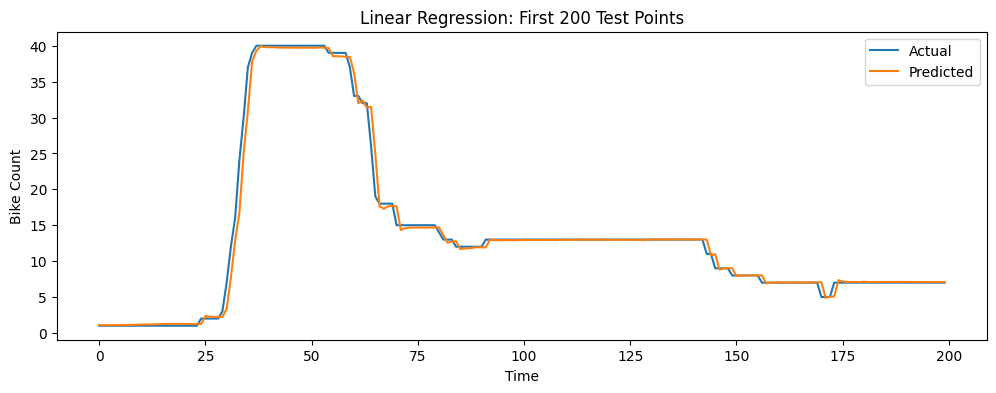

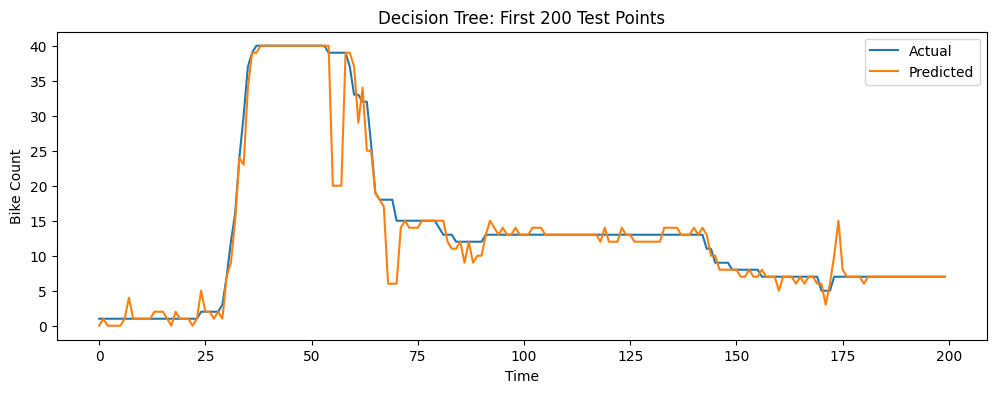

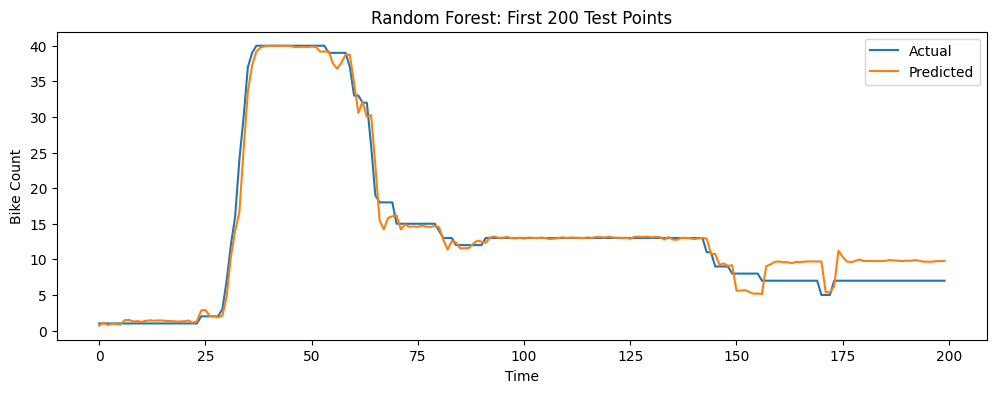

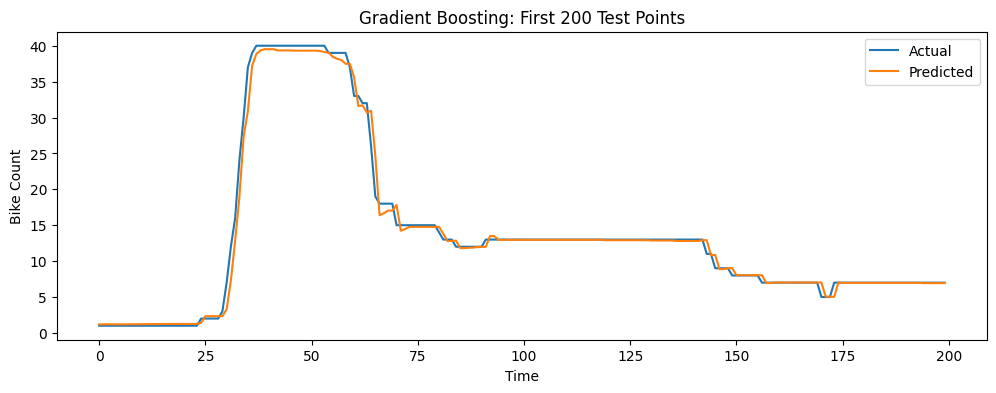

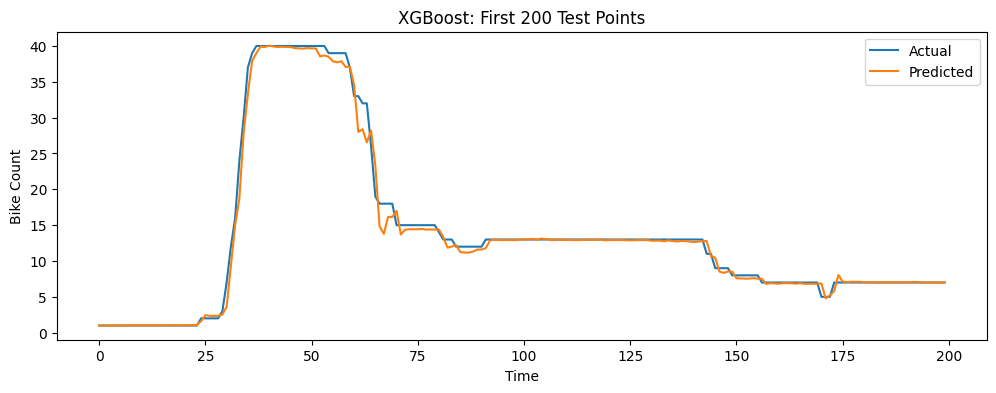

In [26]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

n = 200

models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    plt.figure(figsize=(12, 4))
    plt.plot(y_test.values[:n], label="Actual")
    plt.plot(y_pred[:n], label="Predicted")
    plt.legend()
    plt.title(f"{name}: First {n} Test Points")
    plt.xlabel("Time")
    plt.ylabel("Bike Count")
    plt.show()

## 16. Feature importance (for tree-based models)

This is useful if your best model is a Decision Tree or Random Forest.

In [28]:
import pandas as pd

tree_models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
}

for name, model in tree_models.items():
    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    print(f"\n{name} Feature Importance:")
    print(importance_df.head(15))


Decision Tree Feature Importance:
                          Feature  Importance
18                          lag_1    0.981429
15    max_air_temperature_celsius    0.001511
17  max_relative_humidity_percent    0.001471
26                 rolling_std_24    0.001383
16  air_temperature_std_deviation    0.001286
24                rolling_mean_24    0.001251
21                         lag_24    0.001226
22                        lag_168    0.001143
20                          lag_3    0.001005
23                 rolling_mean_3    0.000994
19                          lag_2    0.000928
1                             lat    0.000922
0                      station_id    0.000855
2                             lon    0.000736
11                       hour_sin    0.000586

Random Forest Feature Importance:
                          Feature  Importance
18                          lag_1    0.981405
15    max_air_temperature_celsius    0.001495
17  max_relative_humidity_percent    0.001478
26        

## 17. Save the best model

In [29]:
import os

best_model_name = "Linear Regression"
best_model = lr_model

print("Best model:", best_model_name)
with open("best_bike_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Saved as best_bike_model.pkl")

Best model: Linear Regression
Saved as best_bike_model.pkl


In [30]:
import os
print(os.getcwd())

/Users/xiya


In [33]:
import os
os.system("open .")

0